## Проект прогнозирования рисков сердечно-сосудистых заболеваний

1. Age (возраст);
2. Sex (пол);
3. Resting_blood_pressure (артериальное давление в состоянии покоя);
4. Serum_cholestoral (уровень холестерина в крови mg/dl);
5. Fasting_blood_sugar (анализ глюкозы в крови натощак (> 120 mg/dl));
6. Maximum_heart_rate_achieved (максимальная частота сердечных сокращений);
7. Exercise_induced_angina (стенокардия при нагрузке),
8. Oldpeak (депрессия ST-сегмента);
9. Slope (наклон пикового сегмента ST при физической нагрузке);
10. Number_of_major_vessels (количество крупных сосудов (0-3), окрашенных с помощью флюороскопии);
11. Resting_electrocardiographic_results (результаты электрокардиографических исследований в покое 0, 1, 2);
12. Thal (3 = норма; 6 = фиксированный дефект; 7 = обратимый дефект);
13. Chest_bin (боль в груди от 1 до 4).


In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

# Анализ данных и предобработка

In [ ]:
# Открываем датасет
df_train = pd.read_csv('/train.csv')
df_train.head()

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


In [ ]:
# Размер таблицы
df_train.shape

(600000, 15)

In [ ]:
# Вывод названия столбцов таблицы
df_train.columns

Index(['ID', 'age', 'sex', 'chest', 'resting_blood_pressure',
       'serum_cholestoral', 'fasting_blood_sugar',
       'resting_electrocardiographic_results', 'maximum_heart_rate_achieved',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'number_of_major_vessels', 'thal', 'class'],
      dtype='object')

In [ ]:
# Описание датасета (типы данных, пропуски)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  

In [ ]:
# Пропущенные значения
df_train.isna().sum()

,0
ID,0
age,0
sex,0
chest,0
resting_blood_pressure,0
serum_cholestoral,0
fasting_blood_sugar,0
resting_electrocardiographic_results,0
maximum_heart_rate_achieved,0
exercise_induced_angina,0


In [ ]:
# Удаляем столбец с ID
df_train_clean = df_train.drop('ID', axis=1)

In [67]:
# Статистика по столбцам
df_train_clean.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,542688.0,54.39,9.09,29.25,48.04,55.10,60.64,79.50
sex,542688.0,0.68,0.47,0.00,0.00,1.00,1.00,1.00
chest,542688.0,3.20,0.90,1.00,3.00,3.00,4.00,4.00
resting_blood_pressure,542688.0,129.68,15.85,89.94,119.62,129.32,139.23,169.90
serum_cholestoral,542688.0,243.85,44.13,129.68,215.43,242.42,271.28,361.15
fasting_blood_sugar,542688.0,0.15,0.36,0.00,0.00,0.00,0.00,1.00
resting_electrocardiographic_results,542688.0,1.02,0.99,0.00,0.00,2.00,2.00,2.00
maximum_heart_rate_achieved,542688.0,150.00,22.65,91.51,136.07,153.40,165.26,208.74
exercise_induced_angina,542688.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
oldpeak,542688.0,1.05,1.14,-0.81,0.00,0.80,1.67,6.80


-- 1. ID (unique identifier)

-- 2. age

-- 3. sex

-- 4. chest pain type (4 values)

-- 5. resting blood pressure

-- 6. serum cholestoral in mg/dl

-- 7. fasting blood sugar > 120 mg/dl

-- 8. resting electrocardiographic results (values 0,1,2)

-- 9. maximum heart rate achieved

-- 10. exercise induced angina

-- 11. oldpeak = ST depression induced by exercise relative to rest

-- 12. the slope of the peak exercise ST segment

-- 13. number of major vessels (0-3) colored by flourosopy

-- 14. thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
Attributes types

Real: 1,4,5,8,10,12
Ordered:11,
Binary: 2,6,9
Nominal:7,3,13

In [ ]:
# Столбцец Chest_bin (боль в груди) принимает значения от 1 до 4
df_train_clean = df_train_clean[(df_train_clean['chest'] >= 1) & (df_train_clean['chest'] <= 4)]

In [ ]:
# Поиск выбросов для числовых признаков
col_num = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'maximum_heart_rate_achieved']

plt.figure(figsize=(10,6))
for i in range(0,len(col_num)):
    plt.subplot(1,len(col_num),i+1)
    sns.boxplot(y=df_train_clean[col_num[i]])
    plt.tight_layout()

In [ ]:
for i in col_num:
    Q1 = df_train[i].quantile(0.25)
    Q3 = df_train[i].quantile(0.75)
    IQR = Q3-Q1
    LowerBound = Q1 - (1.5 * IQR)
    UpperBound = Q3 + (1.5 * IQR)

    df_train_clean = df_train_clean[(df_train_clean[i] >= LowerBound)&(df_train_clean[i] <= UpperBound)]

In [ ]:
plt.figure(figsize=(10,6))
for i in range(0,len(col_num)):
    plt.subplot(1,len(col_num),i+1)
    sns.boxplot(y=df_train_clean[col_num[i]])
    plt.tight_layout()

In [ ]:
df_train_clean[col_num].describe().T

,count,mean,std,min,25%,50%,75%,max
age,542688.0,54.391785,9.089948,29.250955,48.036700,55.101509,60.644517,79.504896
resting_blood_pressure,542688.0,129.681084,15.845437,89.937688,119.622510,129.323508,139.226039,169.900393
serum_cholestoral,542688.0,243.853918,44.127001,129.677123,215.432061,242.423917,271.275121,361.145425
maximum_heart_rate_achieved,542688.0,149.995615,22.646923,91.512519,136.065412,153.397687,165.263608,208.735196


In [ ]:
# Категориальные признаки
categoric_cols = ['sex', 'fasting_blood_sugar', 'resting_electrocardiographic_results',
                  'exercise_induced_angina', 'slope', 'number_of_major_vessels', 'thal']

In [ ]:
for i in categoric_cols:
    if i in df_train_clean.columns:
        print('All values in column {0} : \n{1}'.format(i, df_train_clean[i].value_counts().sort_index()))
        print('\n')
    else:
        print(f'Column {i} not found in the DataFrame.')

# Print the list of categorical columns
print('Categorical columns:', categoric_cols)

All values in column sex : 
sex
0    175736
1    366952
Name: count, dtype: int64


All values in column fasting_blood_sugar : 
fasting_blood_sugar
0    460887
1     81801
Name: count, dtype: int64


All values in column resting_electrocardiographic_results : 
resting_electrocardiographic_results
0    263316
1      6066
2    273306
Name: count, dtype: int64


All values in column exercise_induced_angina : 
exercise_induced_angina
0    361848
1    180840
Name: count, dtype: int64


All values in column slope : 
slope
1    262753
2    237752
3     42183
Name: count, dtype: int64


All values in column number_of_major_vessels : 
number_of_major_vessels
0    320885
1    116030
2     66258
3     39515
Name: count, dtype: int64


All values in column thal : 
thal
3    303905
6     31334
7    207449
Name: count, dtype: int64


Categorical columns: ['sex', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'slope', 'number_of_major_vessels', 'thal']


In [ ]:
df_train_clean.shape

(542688, 14)

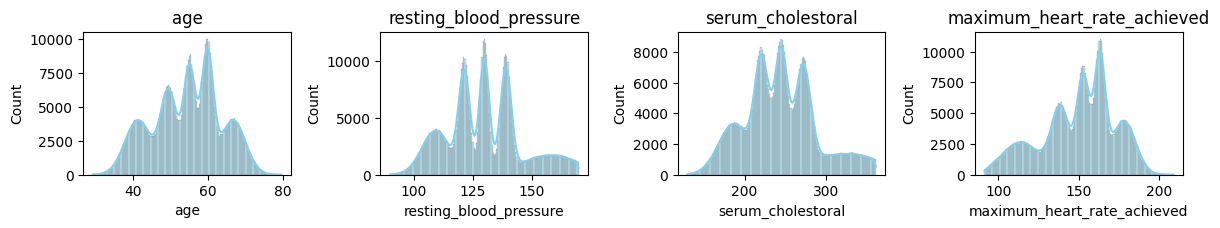

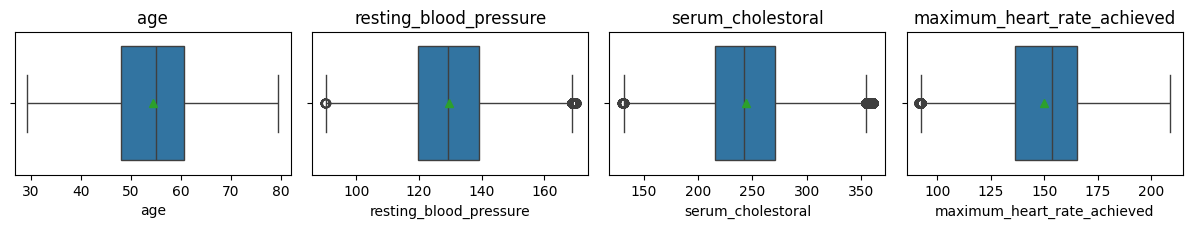

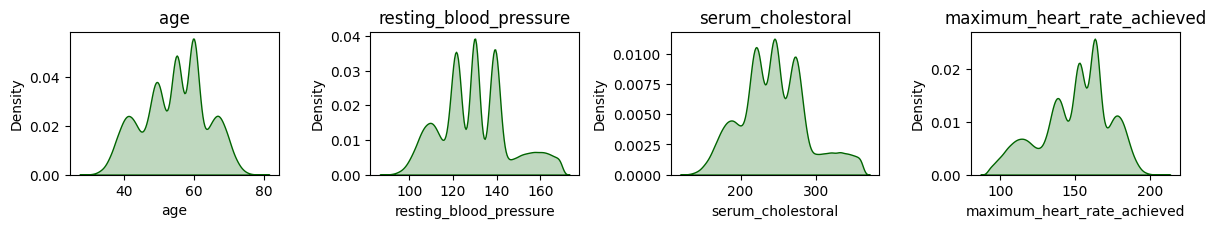

In [68]:
# Визуализация данных

# Гистограммы
plt.figure(figsize=(15, 10))
for i, col in enumerate(col_num):
    plt.subplot(5, 5, i+1)
    sns.histplot(df_train_clean[col], kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(15, 10))
for i, col in enumerate(col_num):
    plt.subplot(5, 5, i+1)
    sns.boxplot(x=df_train_clean[col], showmeans=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Density plots
plt.figure(figsize=(15, 10))
for i, col in enumerate(col_num):
    plt.subplot(5, 5, i+1)
    sns.kdeplot(df_train_clean[col], fill=True, color='darkgreen')
    plt.title(col)
plt.tight_layout()
plt.show()

In [69]:
# Проверка данных на мультиколлинеарность
# Создаем матрицу корреляций
features_df = df_train_clean.drop(['class'], axis=1)
corr_matrix = features_df.corr()

# Определяем ранг матрицы
rank_corr_matrix = np.linalg.matrix_rank(corr_matrix.values)

# Рассчитываем определитель
det_corr_matrix = np.linalg.det(corr_matrix.values)

print(f"Ранг матрицы корреляций: {rank_corr_matrix}")
print(f"Определитель матрицы корреляций: {det_corr_matrix}")

Ранг матрицы корреляций: 13
Определитель матрицы корреляций: 0.3400148082814668


In [ ]:
# Строим матрицу корреляций
corr_matrix = features_df.corr()

# Тепловая карта корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

In [ ]:
# Удаляем столбцы
df_train_ready=df_train_clean.copy()
df_train_ready.drop(['oldpeak'], axis=1, inplace=True)

In [ ]:
# Смотрим на мультиколлинеарность
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = features_df.columns

vif_data['VIF'] = [variance_inflation_factor(features_df.values, i) for i in range(len(features_df.columns))]
pd.set_option('display.max_rows', None)

vif_data.sort_values(by= 'VIF', ascending = False)

,feature,VIF
3,resting_blood_pressure,49.997566
7,maximum_heart_rate_achieved,31.090155
0,age,30.256928
4,serum_cholestoral,28.065332
2,chest,15.643231
10,slope,10.080099
12,thal,8.924293
1,sex,3.629910
9,oldpeak,2.630044
6,resting_electrocardiographic_results,2.084518


In [ ]:
# Удаляем то, что vif > 11
features_df.drop(columns = ['resting_blood_pressure'], inplace = True)

In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] = features_df.columns
vif_data['VIF'] = [variance_inflation_factor(features_df.values, i) for i in range(len(features_df.columns))]
pd.set_option('display.max_rows', None)
vif_data.sort_values(by= 'VIF', ascending = False)

In [ ]:
# Удаляем то, что vif > 11
features_df.drop(columns = ['serum_cholestoral', 'age'], inplace = True)

In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] = features_df.columns
vif_data['VIF'] = [variance_inflation_factor(features_df.values, i) for i in range(len(features_df.columns))]
pd.set_option('display.max_rows', None)
vif_data.sort_values(by= 'VIF', ascending = False)

In [ ]:
features_df.drop(columns = ['chest', 'maximum_heart_rate_achieved'], inplace = True)

In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] = features_df.columns
vif_data['VIF'] = [variance_inflation_factor(features_df.values, i) for i in range(len(features_df.columns))]
pd.set_option('display.max_rows', None)
vif_data.sort_values(by= 'VIF', ascending = False)

,feature,VIF
7,thal,6.837696
5,slope,6.378596
0,sex,3.558404
4,oldpeak,2.494499
2,resting_electrocardiographic_results,1.998095
6,number_of_major_vessels,1.658929
3,exercise_induced_angina,1.628308
1,fasting_blood_sugar,1.159572


In [ ]:
df_train_ready.drop(columns = ['chest', 'maximum_heart_rate_achieved', 'serum_cholestoral', 'age'], inplace = True)

In [ ]:
df_train_ready.info()

## Cтандартизация данных

In [ ]:
# Запись данных в X и y
X = df_train_ready.drop(['class'], axis=1)
y = df_train_ready['class']

# 1. Посчитать среднее и стандартное отклонение для каждого признака
means = X.mean(axis=0)
stds = X.std(axis=0)

# 2. Применение формулы стандартизации
def standardize_column(column, mean, std):
    return (column - mean) / std

# Применяем стандартизацию по каждому столбцу
standardized_X = X.apply(lambda col: standardize_column(col, means[col.name], stds[col.name]))

print(standardized_X)

# Построение моделей машинного обучения

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(standardized_X, y, test_size=0.2, random_state=42)

Логистическая регрессия

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])}")

Logistic Regression:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86     60829
           1       0.83      0.79      0.81     47709

    accuracy                           0.84    108538
   macro avg       0.84      0.83      0.83    108538
weighted avg       0.84      0.84      0.84    108538

ROC-AUC: 0.9138499693531811


Randomforest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
# Базовая модель случайного леса
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Оценка базовой модели
baseline_predictions = rf.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
print(f"Базовая точность случайного леса: {baseline_accuracy * 100:.2f}%")

# Гиперпараметры для перебора
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Используем RandomizedSearchCV для быстрого поиска оптимальных гиперпараметров
rand_search = RandomizedSearchCV(rf, param_grid, n_iter=10, cv=3, random_state=42)
rand_search.fit(X_train, y_train)

# Лучшие гиперпараметры
print("Лучшие гиперпараметры:", rand_search.best_params_)

# Оценка оптимальной модели
optimal_rf = rand_search.best_estimator_  # берем лучший классификатор из RandomizedSearchCV
optimal_predictions = optimal_rf.predict(X_test)
optimal_accuracy = accuracy_score(y_test, optimal_predictions)
print(f"Точность случайного леса с лучшими параметрами: {optimal_accuracy * 100:.2f}%")

# Важность признаков
importance = optimal_rf.feature_importances_
sorted_idx = importance.argsort()[::-1]
important_features = [(X.columns[i], importance[i]) for i in sorted_idx[:3]]
print("Три важнейших признака:")
for feat, imp in important_features:
    print(feat, ": ", round(imp*100, 2), "%")


Базовая точность случайного леса: 78.32%
Лучшие гиперпараметры: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10}
Точность случайного леса с лучшими параметрами: 84.81%
Три важнейших признака:
thal :  32.01 %
number_of_major_vessels :  24.6 %
exercise_induced_angina :  18.19 %


In [46]:
from sklearn.metrics import classification_report
print('\n')
print('Classification Report:')
print(classification_report(y_test, optimal_predictions))



Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87     60829
           1       0.83      0.82      0.83     47709

    accuracy                           0.85    108538
   macro avg       0.85      0.84      0.85    108538
weighted avg       0.85      0.85      0.85    108538



Neural Network

In [ ]:
# Разделение на Train и Validation наборы
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Стандартизация числовых признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Сохраняем scaler для инференса позже
import joblib
joblib.dump(scaler, 'scaler.pkl')

# Определение модели
class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Подготовка к обучению
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

input_size = X_train.shape[1]
model = Net(input_size).to(device)

criterion = nn.BCELoss() # Функция потерь для бинарной классификации
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Преобразуем данные в тензоры PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)

# Цикл обучения
num_epochs = 50

train_losses = []
val_losses = []
train_aucs = []
val_aucs = []
best_auc = 0

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

        # Вычисляем метрики на CPU для sklearn
        outputs_np = outputs.cpu().numpy()
        val_outputs_np = val_outputs.cpu().numpy()

        auc_train = roc_auc_score(y_train_t.cpu().numpy(), outputs_np)
        auc_val = roc_auc_score(y_val_t.cpu().numpy(), val_outputs_np)

        # Сохраняем историю для графиков
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        train_aucs.append(auc_train)
        val_aucs.append(auc_val)

        # Сохранение лучшей модели по AUC на валидации
        if auc_val > best_auc:
            best_auc = auc_val
            torch.save(model.state_dict(), '/content/models/best_model.pth')
            print(f"Epoch {epoch+1}: Модель улучшена. Val AUC: {auc_val:.4f}")

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# Визуализация результатов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss по эпохам')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_aucs, label='Train ROC-AUC')
plt.plot(val_aucs, label='Validation ROC-AUC')
plt.title('ROC-AUC по эпохам')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()

plt.savefig('training_plots.png')
print("График сохранен в файл training_plots.png")

In [ ]:
# Скрипт для запуска инференса

# Определение архитектуры сети
class Net(torch.nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_size, 64)
        self.fc2 = torch.nn.Linear(64, 32)
        self.fc3 = torch.nn.Linear(32, 1)
        self.dropout = torch.nn.Dropout(0.2)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Функция предсказания
def predict(csv_path):
    # Загрузка тестовых данных
    df = pd.read_csv('/test.csv')

    ids = df['ID']
    X_test = df.drop(['ID', 'age', 'serum_cholestoral', 'maximum_heart_rate_achieved', 'oldpeak', 'chest'], axis=1)

    # Приведение и выравнивание столбцов к тому же виду, что и при обучении
    scaler = joblib.load('scaler.pkl')

    X_test_scaled = scaler.transform(X_test)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Создаем модель с той же архитектурой
    model = Net(X_test_scaled.shape[1]).to(device)

    # Загружаем веса
    model.load_state_dict(torch.load('/content/models/best_model.pth'))

    # Переводим модель в режим оценки
    model.eval()

    with torch.no_grad():
        X_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
        predictions = model(X_tensor).cpu().numpy()

    # Создаем DataFrame для сабмита в нужном формате
    submission_df = pd.DataFrame({'ID': ids, 'target': predictions.flatten()})

    # Сохраняем результат в файл submission.csv
    submission_df.to_csv('submission.csv', index=False)
    print("Готово! Файл submission.csv создан.")

# Запуск функции предсказания на тестовом наборе данных
if __name__ == "__main__":
    predict('/test.csv')